In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
from torchvision import models
import torchvision.models as models
import torch.nn as nn
import matplotlib.ticker as ticker

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

BATCH_SIZE = 512
LEARNING_RATE = 0.01
EPOCHS = 200

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)

In [5]:
#NFG_SVRG
class NFG_SVRG_SGD(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["prev_a"] = torch.zeros_like(p) # prev_aを'a'のクローンとして初期化

                state["prev_a"].copy_(state["a"])
                state["a"].zero_()
                state['prev_p'] = torch.clone(p).detach() # prev_pの初期値はパラメータ
                state["t"] = 0

    def culc_prev_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["current_p"] = torch.clone(p) # 現在のパラメータをcurrent_pに保持
                    p.copy_(state["prev_p"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        # current_pに切り替え，prev_gradの保持
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["current_p"]) # パラメータをcurrent_pに変換
                    state["prev_grad"] = torch.clone(p.grad.detach())     

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]

                # 補正勾配
                a = state['a']
                prev_a = state["prev_a"]
                prev_grad = state["prev_grad"]
                t = state["t"]

                # 平均勾配を更新
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))

                # 補正勾配を更新
                v = grad - prev_grad + prev_a

                # パラメータを更新
                p.sub_(v, alpha = lr)
                state["t"] += 1

        return loss


model = models.resnet18(weights=None)
# CIFAR用に変更
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model.fc = nn.Linear(512, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = NFG_SVRG_SGD(model.parameters(), lr = LEARNING_RATE)

NFG_train_loss_x = []
NFG_train_loss = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch; {epoch + 1}")
    model.train()
    train_loss = 0

    optimizer.init_epoch()

    for X, Y in tqdm(trainloader):
        X, Y = X.to(device), Y.to(device)

        optimizer.culc_prev_grads(model, X, Y, criterion)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    fg_count += 2

    NFG_train_loss_x.append(fg_count)
    NFG_train_loss.append(train_loss / len(trainloader))
    print(f"Loss: {train_loss / len(trainloader):.6f}")

    if fg_count >= 1000:
        break

epoch; 1


100%|██████████| 98/98 [00:49<00:00,  1.96it/s]


Loss: 2.393396
epoch; 2


100%|██████████| 98/98 [00:46<00:00,  2.09it/s]


Loss: 2.129561
epoch; 3


...

Loss: 0.527931
epoch; 100


100%|██████████| 98/98 [00:47<00:00,  2.06it/s]


Loss: 0.527407
epoch; 101


 46%|████▌     | 45/98 [00:22<00:26,  2.00it/s]


KeyboardInterrupt: 

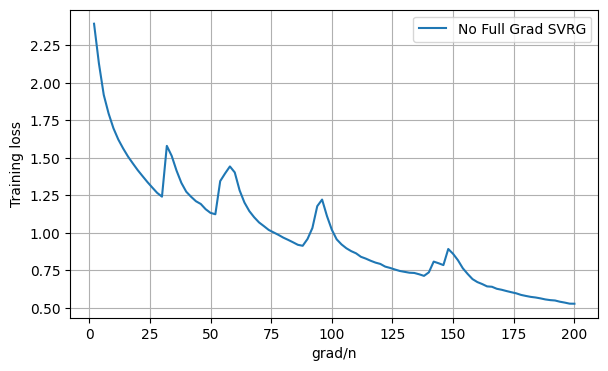

In [6]:
fig = plt.figure(figsize = (15, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(NFG_train_loss_x, NFG_train_loss, label = "No Full Grad SVRG")
ax.set_xlabel("grad/n")
ax.set_ylabel("Training loss")
ax.grid()
ax.legend()